# MAP BUILDER

In [1]:
import argparse
import os

import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import numpy as np
import datetime

import pandas as pd
from pandas import Timestamp
from pandas import Timedelta

from tables import *

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates
from matplotlib.transforms import offset_copy
plt.rcParams['svg.fonttype'] = 'none'

import time
import shutil
import glob
import urllib

from obspy import UTCDateTime
from obspy.geodetics import locations2degrees
from obspy.taup import TauPyModel


from bokeh.plotting import figure, output_file, save, gridplot, show
from bokeh.models import HoverTool, ColumnDataSource, OpenURL, TapTool, Range1d, Div, LinearAxis, Span
from bokeh.models import Arrow, VeeHead, ColorBar, LogColorMapper, LogTicker, Span
from bokeh.layouts import column
from bokeh.io import export_svgs

try:
    import urllib2
except:
    pass

import data.grlplotprops as grl# kernel has to be restarted everytime this file is changed

### Load STUB data

In [2]:
# load and process BMKG event catalog
bmkg = pd.read_csv('./BMKGcatalog4Jay.txt', parse_dates=[3], index_col=[3]).tz_localize('UTC')#.tz_convert('Asia/Singapore')
#bmkg = bmkg['2017-11-08 00:00:00':'2018-02-28 23:59:59'] # optional time filter
#bmkg = bmkg[:'2017-10-15 00:00:00'] # optional time filter
print(len(bmkg))

# Convert BMKG Catalog to heatmap based on location
bmkg_heatmap = bmkg.groupby(['lat', 'lon']).agg('size') 
# Save heatmap in dataframe
bmkg_heatmap = pd.DataFrame({
    'lat':   bmkg_heatmap.index.get_level_values(0),
    'lon':   bmkg_heatmap.index.get_level_values(1),
    'count': bmkg_heatmap.values
}) 
bmkg_heatmap

from bokeh.palettes import Spectral6
from bokeh.transform import linear_cmap
mapper = linear_cmap(field_name='count', palette=Spectral6 ,low=min(bmkg_heatmap['count']), high=max(bmkg_heatmap['count']))

440


In [3]:
############ Define Radial Map Extent ######################################
from functools import partial
import pyproj
from shapely.ops import transform
from shapely.geometry import Point

proj_wgs84 = pyproj.Proj(init='epsg:4326') # This throws a Future Warning
#proj_wgs84 = pyproj.Proj('epsg:4326')      # This should be the new syntax

def geodesic_point_buffer(lat, lon, km):
    # Azimuthal equidistant projection
    aeqd_proj = '+proj=aeqd +lat_0={lat} +lon_0={lon} +x_0=0 +y_0=0'
    project = partial(
        pyproj.transform,
        pyproj.Proj(aeqd_proj.format(lat=lat, lon=lon)),
        proj_wgs84)
    buf = Point(0, 0).buffer(km * 1000)  # distance in metres
    
    lon = []; lat = []
    for p in transform(project, buf).exterior.coords[:]:
        lon.append(p[0])
        lat.append(p[1])
    
    return transform(project, buf).exterior.coords[:], lat, lon

# Example
radius, rlat, rlon = geodesic_point_buffer(-8.343, 115.508, 15)
radius10k, lat10kmr, lon10kmr = geodesic_point_buffer(-8.343, 115.508, 10)

map_extent = [min(rlon), max(rlon), min(rlat), max(rlat)]
############################################################################

/Users/jwellik/opt/anaconda3/envs/seismology38/lib/python3.8/site-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


      lat     lon  count
0   -8.78  115.30      1
1   -8.77  115.25      1
2   -8.74  115.20      1
3   -8.74  115.44      1
4   -8.74  115.61      1
..    ...     ...    ...
146 -8.10  115.34      1
147 -8.09  115.34      1
148 -8.09  115.44      1
149 -8.04  115.37      1
150 -8.03  115.48      1

[151 rows x 3 columns]


/Users/jwellik/opt/anaconda3/envs/seismology38/lib/python3.8/site-packages/cartopy/crs.py:825: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(multi_line_string) > 1:
/Users/jwellik/opt/anaconda3/envs/seismology38/lib/python3.8/site-packages/cartopy/crs.py:877: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for line in multi_line_string:
/Users/jwellik/opt/anaconda3/envs/seismology38/lib/python3.8/site-packages/cartopy/crs.py:944: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(p_mline) > 0:


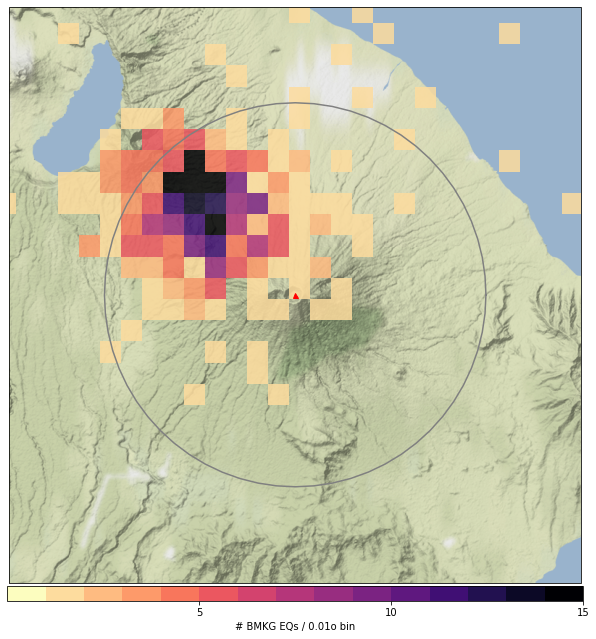

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend
from matplotlib.collections import EventCollection
from matplotlib.patches import Rectangle
import matplotlib as mpl
import numpy as np
import matplotlib.dates as mdates
import pandas as pd

from mpl_toolkits.axes_grid1 import Divider, Size
from mpl_toolkits.axes_grid1.mpl_axes import Axes
plt.rcParams['svg.fonttype'] = 'none'

#import grlplotprops as grl

#from mpl_toolkits.basemap import Basemap

# set figure and axis dimensions
# define and set margins
fig_width_in  = 20
fig_height_in = 20
fontname = 'Arial'
fontsize = 8

# Figure/Axis dimensions (inches)
top_margin = 0.5

# map position (inches)
mWin = 8
mHin = mWin
mmL = 0.0
mmB = 0.75
mmT = top_margin

# map colorbar position (inches)
cbL = mmL
cbB = 0.5
cbW = mWin
cbH = 0.2


# Axis bounds (l,b,w,h)
# Convert position from inches to relative-figure location
#a = list(np.array([1, 2, 3, 4])/5)
#a
map_bounds    = [mmL/fig_width_in, mmB/fig_height_in, mWin/fig_width_in, mHin/fig_height_in]
cbar_bounds   = [cbL/fig_width_in, cbB/fig_height_in, cbW/fig_width_in, cbH/fig_width_in]
#legend_bounds = [legL/fig_width_in, legB/fig_height_in, legW/fig_width_in, legH/fig_width_in]


# create figure
# https://stackoverflow.com/questions/46105333/creating-multiple-y-axis-on-both-sides
#matplotlib.rcParams['font.family'] = grl.fontname
#matplotlib.rcParams['font.size'] = grl.fontsize
fig = plt.figure(figsize=[fig_width_in,fig_height_in])


######## DEFINE MAP AXES ##################################
import cartopy.crs as ccrs
from cartopy.io.img_tiles import Stamen
tiler = Stamen('terrain-background')
mercator = tiler.crs
axm = fig.add_subplot(1,1,1, projection=mercator)
axm.set_extent(map_extent, crs=ccrs.PlateCarree())
axm.add_image(tiler, 12)
axm.yaxis.tick_right()
axm.set_position(map_bounds)
#plt.title('Agung (lat, lon, 10km radius)', fontsize=grl.fontsize, loc='left')
#################################################################




######## MAP ##################################
######## 10km radius ##################################
# Create 10km radius
axm.plot(lon10kmr, lat10kmr, 'grey',
       transform=ccrs.PlateCarree())
#################################################################


######## Create Heat Map #########################################
lon = bmkg_heatmap['lon'].values
lat = bmkg_heatmap['lat'].values
c = bmkg_heatmap['count'].values

from matplotlib import cm
ncmap = 15 # hard-coded number of steps in the colormap
cmap = cm.get_cmap('magma_r', ncmap)
colors = []
print(bmkg_heatmap)
for c in bmkg_heatmap['count'].values:
#    colors.append(cmap(int(c/max(bmkg_heatmap['count'].values)*ncmap)))
    colors.append(cmap(int(c/15*ncmap)))

grid_size = 0.01/2
for x,y,c in zip(lon,lat,colors):
    heat_map_final = axm.fill([x-grid_size, x-grid_size, x+grid_size, x+grid_size, x-grid_size],
            [y-grid_size, y+grid_size, y+grid_size, y-grid_size, y-grid_size],
           color=c[0:3], alpha=0.85, linewidth=0,
           transform=ccrs.PlateCarree())
    
img = plt.imshow(np.array([[0,15]]), cmap='coolwarm')
img.set_visible(False)

cax = fig.add_axes(cbar_bounds)
#cmap = mpl.cm.cool
bounds = np.linspace(0,15,16)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
#norm = mpl.colors.Normalize(vmin=0, vmax=15)
cb = mpl.colorbar.ColorbarBase(cax,
                cmap=cmap, norm=norm, boundaries=bounds, ticks=[5,10,15],
                orientation='horizontal')
cb.set_label('# BMKG EQs / 0.01o bin')    
#################################################################
    
######## Volcano Coords #########################################
# plot volcano coordinates
volc = [
    dict({'name':'Agung', 'lat':-8.343, 'lon':115.508, 'elev':2997}),
#    dict({'name':'Batur', 'lat':-8.242, 'lon':115.375, 'elev':1717}),    
]


stations = [
    dict({'name':'TMKS', 'lon':115.46675, 'lat':-8.36383, 'used':True}),
    dict({'name':'PSAG', 'lon':115.49872, 'lat':-8.37769, 'used':True}),
    dict({'name':'ABNG', 'lon':115.43476667, 'lat':-8.29436667, 'used':True}),
    dict({'name':'YHKR', 'lon':115.50838252, 'lat':-8.38157119, 'used':True}),
    dict({'name':'CEGI', 'lon':115.4716111, 'lat':-8.30494, 'used':True}),

    dict({'name':'BTR', 'lon':115.37636, 'lat':-8.24523, 'used':False}),
    dict({'name':'REND', 'lon':115.43167611, 'lat':-8.42471940, 'used':False}),
    dict({'name':'DUKU', 'lon':115.5341944, 'lat':-8.29586, 'used':False}),
    dict({'name':'BATU', 'lon':115.49954, 'lat':-8.20885, 'used':False}),
    dict({'name':'DNU', 'lon':115.38533, 'lat':-8.26944, 'used':False}),
    dict({'name':'DNU', 'lon':115.38853, 'lat':-8.23, 'used':False}),
]

for v in volc:
    axm.plot(v['lon'], v['lat'], '^r', mfc='red', markersize=5,
            transform=ccrs.PlateCarree())
#################################################################
#################################################################  

### Plot vertical profile